 **1: Environment Setup**

In [1]:
# Install all required libraries
# ------------------------------
!pip install -q ultralytics kaggle opencv-python-headless pandas matplotlib pyyaml tqdm transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.4 MB/s eta 0:00:00


In [2]:
# Import Libraries
# ------------------------------
from pathlib import Path
from collections import defaultdict, Counter
from google.colab import files
import os, random, shutil, subprocess, yaml, re

import cv2
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from ultralytics import YOLO
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
from IPython.display import display, Image as IPyImage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Global Settings
DATASET_SLUG         = "muhammadsubhanfurjam/retail-product-checkout-yolo"
WORK_DIR             = Path("/content/retail_checkout")
RAW_DIR              = WORK_DIR / "raw"
SAMPLED_DIR          = WORK_DIR / "sampled_dataset"
OUTPUT_DIR           = WORK_DIR / "outputs"
RUNS_DIR             = WORK_DIR / "runs"
PRICES_CSV           = WORK_DIR / "product_prices.csv"

# Dataset sampling settings
USE_FULL_DATASET     = False
MAX_TRAIN_IMAGES     = 3000
MAX_VAL_IMAGES       = 500
MAX_TEST_IMAGES      = 100
FORCE_REBUILD_SAMPLE = True

# Model training settings
MODEL_NAME           = "yolov8n.pt"
EPOCHS               = 50
IMGSZ                = 640
BATCH                = 32
SEED                 = 42

# Detection thresholds
CONF_THRESHOLD       = 0.09
IOU_THRESHOLD        = 0.4

for d in [WORK_DIR, RAW_DIR, OUTPUT_DIR, RUNS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
print("CUDA available:", torch.cuda.is_available())
print("Settings ready ✅")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA available: True
Settings ready ✅


**2: Dataset Preparation**

In [4]:
# Download Dataset from Kaggle
# ------------------------------
def ensure_kaggle_credentials():
    kaggle_json = Path.home() / ".kaggle" / "kaggle.json"
    if kaggle_json.exists():
        os.chmod(kaggle_json, 0o600)
        print("Kaggle credentials found ✅")
        return
    print("Upload kaggle.json:")
    uploaded = files.upload()
    if not uploaded:
        raise FileNotFoundError("No Kaggle token uploaded.")
    kaggle_json.parent.mkdir(parents=True, exist_ok=True)
    shutil.move(next(iter(uploaded.keys())), kaggle_json)
    os.chmod(kaggle_json, 0o600)
    print("Kaggle credentials saved ✅")

def download_dataset():
    if list(RAW_DIR.rglob("*.yaml")):
        print("Dataset already exists in", RAW_DIR)
        return
    ensure_kaggle_credentials()
    subprocess.run(
        ["kaggle", "datasets", "download", "-d", DATASET_SLUG,
         "-p", str(RAW_DIR), "--unzip"],
        check=True
    )
    print("Dataset downloaded to", RAW_DIR)

download_dataset()
print("Contents:", os.listdir(RAW_DIR))

Dataset already exists in /content/retail_checkout/raw
Contents: ['Retail_Product_Checkout_YOLO_TXT']


In [5]:
# Read Dataset Classes
# ------------------------------

# Parse YOLO dataset YAML to extract class names and split paths
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def load_yaml(path):
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)

def write_yaml(data, path):
    with open(path, "w", encoding="utf-8") as f:
        yaml.safe_dump(data, f, sort_keys=False, allow_unicode=True)

def find_source_yaml(base_dir):
    candidates = sorted(
        list(base_dir.rglob("*.yaml")) + list(base_dir.rglob("*.yml"))
    )
    if not candidates:
        raise FileNotFoundError("No YAML found in dataset.")
    for name in ["dataset_ready.yaml", "data.yaml", "dataset.yaml"]:
        for path in candidates:
            if path.name == name:
                return path
    return candidates[0]

def find_split_dir(root, split_names):
    for split in split_names:
        for candidate in [
            root / split / "images",
            root / "images" / split,
            root / split
        ]:
            if candidate.exists() and any(
                p.suffix.lower() in IMG_EXTS for p in candidate.rglob("*")
            ):
                return candidate
    return None

def class_names_from_yaml(data):
    names = data.get("names", [])
    if isinstance(names, dict):
        return [str(names[k]) for k in sorted(
            names,
            key=lambda v: (0, int(v)) if str(v).isdigit() else (1, str(v))
        )]
    return [str(x) for x in names]

SOURCE_YAML   = find_source_yaml(RAW_DIR)
SOURCE_ROOT   = SOURCE_YAML.parent
SOURCE_DATA   = load_yaml(SOURCE_YAML)
CLASS_NAMES   = class_names_from_yaml(SOURCE_DATA)

TRAIN_IMG_DIR = find_split_dir(SOURCE_ROOT, ["train", "training"])
VAL_IMG_DIR   = find_split_dir(SOURCE_ROOT, ["val", "valid", "validation"])
TEST_IMG_DIR  = find_split_dir(SOURCE_ROOT, ["test", "testing"])

print(f"Source YAML : {SOURCE_YAML}")
print(f"Classes     : {len(CLASS_NAMES)}")
print(f"Train dir   : {TRAIN_IMG_DIR}")
print(f"Val dir     : {VAL_IMG_DIR}")
print(f"Test dir    : {TEST_IMG_DIR}")
print(f"Sample classes: {CLASS_NAMES[:5]}")

Source YAML : /content/retail_checkout/raw/Retail_Product_Checkout_YOLO_TXT/dataset_ready.yaml
Classes     : 200
Train dir   : /content/retail_checkout/raw/Retail_Product_Checkout_YOLO_TXT/train/images
Val dir     : /content/retail_checkout/raw/Retail_Product_Checkout_YOLO_TXT/val/images
Test dir    : /content/retail_checkout/raw/Retail_Product_Checkout_YOLO_TXT/test/images
Sample classes: ['112_canned_food', '111_canned_food', '103_milk', '87_drink', '92_alcohol']


In [6]:
# Clean Class Names
# ------------------------------

def clean_class_name(name):
    cleaned = re.sub(r'^\d+_', '', str(name))
    cleaned = cleaned.replace("_", " ").strip()
    return cleaned

CLEAN_CLASS_NAMES = [clean_class_name(n) for n in CLASS_NAMES]
CLASS_NAME_MAP    = {orig: clean for orig, clean in zip(CLASS_NAMES, CLEAN_CLASS_NAMES)}
UNIQUE_CLEAN_NAMES = list(dict.fromkeys(CLEAN_CLASS_NAMES))

print(f"Original classes : {len(CLASS_NAMES)}")
print(f"Unique categories: {len(UNIQUE_CLEAN_NAMES)}")
print(f"\n17 Categories:")
for i, name in enumerate(UNIQUE_CLEAN_NAMES, 1):
    count = CLEAN_CLASS_NAMES.count(name)
    print(f"  {i:2d}. {name:25s} ({count} sub-classes)")

Original classes : 200
Unique categories: 17

17 Categories:
   1. canned food               (14 sub-classes)
   2. milk                      (11 sub-classes)
   3. drink                     (15 sub-classes)
   4. alcohol                   (11 sub-classes)
   5. personal hygiene          (10 sub-classes)
   6. tissue                    (20 sub-classes)
   7. candy                     (10 sub-classes)
   8. dessert                   (17 sub-classes)
   9. stationery                (7 sub-classes)
  10. seasoner                  (12 sub-classes)
  11. puffed food               (12 sub-classes)
  12. gum                       (8 sub-classes)
  13. dried food                (9 sub-classes)
  14. dried fruit               (9 sub-classes)
  15. instant drink             (11 sub-classes)
  16. chocolate                 (12 sub-classes)
  17. instant noodles           (12 sub-classes)


In [7]:
# Prepare Balanced Dataset
# ------------------------------

def label_dir_for(img_dir):
    img_dir = Path(img_dir)
    if img_dir.name == "images":
        return img_dir.parent / "labels"
    return img_dir.parent / "labels" / img_dir.name

def image_label_pairs(img_dir):
    label_dir = label_dir_for(img_dir)
    pairs = []
    for img_path in sorted(img_dir.rglob("*")):
        if img_path.suffix.lower() not in IMG_EXTS:
            continue
        rel        = img_path.relative_to(img_dir)
        label_path = label_dir / rel.with_suffix(".txt")
        if label_path.exists():
            pairs.append((img_path, label_path, rel))
    return pairs

def primary_class(label_path):
  # Extract the primary class ID from a YOLO label file
    try:
        with open(label_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    return parts[0]
    except Exception:
        pass
    return "empty"

def balanced_sample(pairs, max_images):
    # Sample equally from each class to avoid imbalance
    if not max_images or max_images >= len(pairs):
        return random.sample(pairs, len(pairs))
    groups = defaultdict(list)
    for pair in pairs:
        groups[primary_class(pair[1])].append(pair)
    for items in groups.values():
        random.shuffle(items)
    sampled, group_lists = [], [list(v) for v in groups.values()]
    while len(sampled) < max_images and any(group_lists):
        for items in group_lists:
            if items and len(sampled) < max_images:
                sampled.append(items.pop())
    return sampled

def copy_pairs(pairs, dst_root, split_name):
    # Copy sampled image-label pairs to the sampled dataset directory
    img_dst = dst_root / split_name / "images"
    lbl_dst = dst_root / split_name / "labels"
    for img_path, label_path, rel in tqdm(pairs, desc=f"Copy {split_name}"):
        (img_dst / rel).parent.mkdir(parents=True, exist_ok=True)
        (lbl_dst / rel.with_suffix(".txt")).parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(img_path, img_dst / rel)
        shutil.copy2(label_path, lbl_dst / rel.with_suffix(".txt"))

def prepare_dataset():
    fixed_yaml = WORK_DIR / "data_sampled.yaml"
    if SAMPLED_DIR.exists() and fixed_yaml.exists() and not FORCE_REBUILD_SAMPLE:
        print("Using existing sampled dataset ✅")
        return SAMPLED_DIR, fixed_yaml

    if SAMPLED_DIR.exists():
        shutil.rmtree(SAMPLED_DIR)
        print("Removed old sampled dataset")

    train_sample = balanced_sample(image_label_pairs(TRAIN_IMG_DIR), MAX_TRAIN_IMAGES)
    val_sample   = balanced_sample(image_label_pairs(VAL_IMG_DIR),   MAX_VAL_IMAGES)
    test_pairs   = image_label_pairs(TEST_IMG_DIR) if TEST_IMG_DIR else []
    test_sample  = balanced_sample(test_pairs, MAX_TEST_IMAGES)

    copy_pairs(train_sample, SAMPLED_DIR, "train")
    copy_pairs(val_sample,   SAMPLED_DIR, "val")
    if test_sample:
        copy_pairs(test_sample, SAMPLED_DIR, "test")

    data = {
        "path":  str(SAMPLED_DIR),
        "train": "train/images",
        "val":   "val/images",
        "names": CLASS_NAMES,
    }
    if test_sample:
        data["test"] = "test/images"
    write_yaml(data, fixed_yaml)

    print(f"Dataset ready ✅")
    print(f"Train: {len(train_sample)} | Val: {len(val_sample)} | Test: {len(test_sample)}")
    return SAMPLED_DIR, fixed_yaml

TRAIN_DATA_ROOT, TRAIN_DATA_YAML = prepare_dataset()

# Count actual images in each split
train_imgs = [p for p in (SAMPLED_DIR/"train"/"images").rglob("*") if p.suffix.lower() in IMG_EXTS]
val_imgs   = [p for p in (SAMPLED_DIR/"val"/"images").rglob("*")   if p.suffix.lower() in IMG_EXTS]
test_imgs  = [p for p in (SAMPLED_DIR/"test"/"images").rglob("*")  if p.suffix.lower() in IMG_EXTS] if (SAMPLED_DIR/"test").exists() else []

print("=" * 40)
print(f"Train images : {len(train_imgs)}")
print(f"Val   images : {len(val_imgs)}")
print(f"Test  images : {len(test_imgs)}")
print(f"Total        : {len(train_imgs)+len(val_imgs)+len(test_imgs)}")
print("=" * 40)

Copy train:   0%|          | 0/3000 [00:00<?, ?it/s]

Copy val:   0%|          | 0/500 [00:00<?, ?it/s]

Copy test:   0%|          | 0/100 [00:00<?, ?it/s]

Dataset ready ✅
Train: 3000 | Val: 500 | Test: 100
Train images : 3000
Val   images : 500
Test  images : 100
Total        : 3600


**3: Model Training**

In [ ]:
# Fine-tune YOLOv8 on RPC Dataset
# ------------------------------
#   Copy-Paste Augmentation for occlusion handling
#   AdamW optimizer for better convergence
# YOLO handles detection (bounding boxes only)

def train_yolo():
    device = 0 if torch.cuda.is_available() else "cpu"
    print(f"Training on: {device}")
    model   = YOLO(MODEL_NAME)
    results = model.train(
        data          = str(TRAIN_DATA_YAML),
        epochs        = EPOCHS,
        imgsz         = IMGSZ,
        batch         = BATCH,
        optimizer     = "AdamW",
        lr0           = 0.01,
        lrf           = 0.01,
        warmup_epochs = 5,
        freeze        = 0,
        patience      = 30,
        mosaic        = 1.0,  # mosaic augmentation
        mixup         = 0.1,  # mixup augmentation
        copy_paste    = 0.3,  # copy-paste augmentation for occlusion
        hsv_h         = 0.015,
        hsv_s         = 0.7,
        hsv_v         = 0.4,
        scale         = 0.5,
        fliplr        = 0.5,
        flipud        = 0.1,
        cache         = "disk",
        workers       = 2,
        device        = device,
        project       = str(RUNS_DIR),
        name          = "yolo_rpc_v2",
        exist_ok      = True,
    )
    best = Path(results.save_dir) / "weights" / "best.pt"
    print(f"Best model saved: {best} ✅")
    return best

MODEL_PATH = train_yolo()
print("Model ready:", MODEL_PATH)

Training on: 0
Ultralytics 8.4.49 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/retail_checkout/data_sampled.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_rpc_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overl

In [ ]:
# Save Trained Model to local device
# to reload the model in future sessions without retraining
os.makedirs("/content/saved_model", exist_ok=True)
shutil.copy(MODEL_PATH, "/content/saved_model/rpc_best.pt")
files.download("/content/saved_model/rpc_best.pt")
print("Model downloaded to your device ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model downloaded to your device ✅


In [9]:
# Upload the previously saved rpc_best.pt file
print("Upload rpc_best.pt:")
uploaded      = files.upload()
model_path    = list(uploaded.keys())[0]
MODEL_PATH    = Path(model_path)
trained_model = YOLO(str(MODEL_PATH))
print(f"Model loaded successfully ✅")

Upload rpc_best.pt:


Saving rpc_best.pt to rpc_best.pt
Model loaded successfully ✅


**4: Model Evaluation**

In [10]:
# Evaluate the fine-tuned YOLO model on the validation set
# ------------------------------
# These metrics reflect YOLO detection performance only
# CLIP classification improves the final output
metrics = trained_model.val(data=str(TRAIN_DATA_YAML))
print("\n===== Evaluation Results =====")
print(f"mAP@50:    {metrics.box.map50:.3f}")
print(f"mAP@50-95: {metrics.box.map:.3f}")
print(f"Precision: {metrics.box.mp:.3f}")
print(f"Recall:    {metrics.box.mr:.3f}")

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,371,024 parameters, 0 gradients, 9.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2368.9±972.2 MB/s, size: 219.2 KB)
val: Scanning /content/retail_checkout/sampled_dataset/val/labels... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 1.4Kit/s 0.4s
val: New cache created: /content/retail_checkout/sampled_dataset/val/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 3.3it/s 9.8s
                   all        500       5938    0.00398     0.0608    0.00207    0.00152
       112_canned_food         27         45          0          0          0          0
       111_canned_food         21         43     0.0327      0.116    0.00492    0.00399
              103_milk         17         31      0.012     0.0968    0.00156    0.00111
              87_drink         16       

**5: Classification & Pricing Setup**

In [11]:
# Load CLIP model
# ------------------------------
# CLIP classifies each detected crop into one of the 17 clean RPC categories using natural language descriptions
# This improves classification accuracy over YOLO alone

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

clip_model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def classify_with_clip(crop_rgb, labels=None):
    """
    Uses detailed descriptions from CSV for better classification
    """
    if crop_rgb.size == 0:
        return UNIQUE_CLEAN_NAMES[0], 0.0

    image  = Image.fromarray(crop_rgb)

    # Use detailed descriptions from CSV instead of short category names
    inputs = clip_processor(
        text           = CLIP_LABELS_DESC,
        images         = image,
        return_tensors = "pt",
        padding        = True
    ).to(device)

    with torch.no_grad():
        probs = clip_model(**inputs).logits_per_image.softmax(dim=1)

    idx        = probs.argmax().item()
    conf       = probs[0][idx].item()
    clean_name = UNIQUE_CLEAN_NAMES[idx]

    return clean_name, conf

print("CLIP with CSV descriptions ready ✅")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP with CSV descriptions ready ✅


In [12]:
# Create detailed text descriptions for each category
# These descriptions help CLIP better understand what to look for
# ------------------------------

DESCRIPTIONS_CSV = WORK_DIR / "clip_descriptions.csv"

def create_descriptions_csv():
    descriptions = {
        "canned food":      "a tin or can of canned food, preserved food in metal container",
        "milk":             "a carton or bottle of milk, dairy milk product, white liquid",
        "drink":            "a can or bottle of drink, soda, juice, beverage, soft drink",
        "alcohol":          "a bottle or can of alcohol, beer, wine, liquor",
        "personal hygiene": "soap, shampoo, lotion, toothpaste, personal care product",
        "tissue":           "tissue paper, paper towel, napkin, facial tissue box",
        "candy":            "candy, sweet, lollipop, hard candy, sugar candy",
        "dessert":          "dessert, cake, pastry, sweet snack, cream filled snack",
        "stationery":       "pen, pencil, notebook, stationery, office supply",
        "seasoner":         "seasoning, sauce, condiment, spice, vinegar, soy sauce",
        "puffed food":      "chips, puffed snack, crackers, popcorn, crispy snack bag",
        "gum":              "chewing gum, bubble gum, mint gum, gum stick pack",
        "dried food":       "dried food, jerky, dried meat, dried snack package",
        "dried fruit":      "dried fruit, raisins, dried mango, nuts, trail mix bag",
        "instant drink":    "instant drink powder, instant coffee, instant tea sachet",
        "instant noodles":  "instant noodles, ramen, cup noodles, instant pasta pack",
        "chocolate":        "chocolate bar, chocolate candy, cocoa chocolate, Hershey KitKat",
    }

    df = pd.DataFrame([
        {"category": name, "description": desc}
        for name, desc in descriptions.items()
    ])
    df.to_csv(DESCRIPTIONS_CSV, index=False)
    print(f"Descriptions CSV created: {DESCRIPTIONS_CSV} ✅")
    return df

def load_descriptions_csv():
    if DESCRIPTIONS_CSV.exists():
        df = pd.read_csv(DESCRIPTIONS_CSV)
        print(f"Descriptions CSV loaded ✅ ({len(df)} categories)")
    else:
        df = create_descriptions_csv()
    return df

# Load descriptions and build CLIP label list
desc_df = load_descriptions_csv()
display(desc_df)
CLIP_DESCRIPTIONS = dict(zip(desc_df["category"], desc_df["description"]))
CLIP_LABELS_DESC  = [CLIP_DESCRIPTIONS[name] for name in UNIQUE_CLEAN_NAMES]

print("\nMappings ready ✅")

Descriptions CSV created: /content/retail_checkout/clip_descriptions.csv ✅


,category,description
0,canned food,"a tin or can of canned food, preserved food in..."
1,milk,"a carton or bottle of milk, dairy milk product..."
2,drink,"a can or bottle of drink, soda, juice, beverag..."
3,alcohol,"a bottle or can of alcohol, beer, wine, liquor"
4,personal hygiene,"soap, shampoo, lotion, toothpaste, personal ca..."
5,tissue,"tissue paper, paper towel, napkin, facial tiss..."
6,candy,"candy, sweet, lollipop, hard candy, sugar candy"
7,dessert,"dessert, cake, pastry, sweet snack, cream fill..."
8,stationery,"pen, pencil, notebook, stationery, office supply"
9,seasoner,"seasoning, sauce, condiment, spice, vinegar, s..."



Mappings ready ✅


In [13]:
# Price database for all 17 RPC categories (prices in SAR)
# ------------------------------

CATEGORY_PRICE = {
    "canned food":      5.0,
    "milk":             3.0,
    "drink":            4.0,
    "alcohol":          15.0,
    "personal hygiene": 8.0,
    "tissue":           3.0,
    "candy":            2.5,
    "dessert":          6.0,
    "stationery":       4.0,
    "seasoner":         5.0,
    "puffed food":      4.0,
    "gum":              2.0,
    "dried food":       6.0,
    "dried fruit":      7.0,
    "instant drink":    3.5,
    "instant noodles":  2.5,
    "chocolate":        5.0,
}

# Rules for complementary product recommendations
CATEGORY_COMPLEMENTS = {
    "drink":           ["puffed food", "candy", "chocolate"],
    "instant drink":   ["puffed food", "candy"],
    "milk":            ["chocolate", "dessert", "candy"],
    "puffed food":     ["drink", "instant drink"],
    "chocolate":       ["milk", "drink", "candy"],
    "candy":           ["drink", "chocolate"],
    "instant noodles": ["drink", "seasoner"],
    "dessert":         ["milk", "drink"],
    "dried fruit":     ["drink", "candy"],
    "dried food":      ["seasoner", "drink"],
    "canned food":     ["seasoner", "drink"],
    "seasoner":        ["instant noodles", "canned food"],
    "tissue":          ["personal hygiene"],
    "personal hygiene":["tissue"],
    "gum":             ["drink", "candy"],
    "alcohol":         ["puffed food", "dried food"],
    "stationery":      [],
}

def load_price_table(unique_names):
    if PRICES_CSV.exists():
        prices = pd.read_csv(PRICES_CSV)
        print("Loaded existing price table ✅")
    else:
        prices = pd.DataFrame({
            "product":     unique_names,
            "price":       [CATEGORY_PRICE.get(n, 3.0) for n in unique_names],
            "category":    unique_names,
            "tags":        [n.replace(" ", "_") for n in unique_names],
            "complements": [", ".join(CATEGORY_COMPLEMENTS.get(n, [])) for n in unique_names],
        })
        prices.to_csv(PRICES_CSV, index=False)
        print("Price table created ✅")

    prices["price"] = pd.to_numeric(prices["price"], errors="coerce").fillna(3.0)
    return prices

def smart_recommendations(detected_products, top_k=5):
    detected_set = set(detected_products)
    recommended  = []
    seen         = set()

    for product in detected_set:
        for related in CATEGORY_COMPLEMENTS.get(product, []):
            if related not in detected_set and related not in seen:
                seen.add(related)
                recommended.append({
                    "Suggested Product": related,
                    "Price (SAR)":       CATEGORY_PRICE.get(related, 3.0),
                    "Reason":            f"goes well with {product}"
                })

    # Suggest popular items if no complements found
    if not recommended:
        fallback = [n for n in UNIQUE_CLEAN_NAMES if n not in detected_set][:top_k]
        recommended = [{
            "Suggested Product": n,
            "Price (SAR)":       CATEGORY_PRICE.get(n, 3.0),
            "Reason":            "popular item"
        } for n in fallback]

    return pd.DataFrame(recommended[:top_k])

PRICE_TABLE = load_price_table(UNIQUE_CLEAN_NAMES)
print(f"Price table ready: {len(PRICE_TABLE)} categories ✅")
display(PRICE_TABLE)

Price table created ✅
Price table ready: 17 categories ✅


,product,price,category,tags,complements
0,canned food,5.0,canned food,canned_food,"seasoner, drink"
1,milk,3.0,milk,milk,"chocolate, dessert, candy"
2,drink,4.0,drink,drink,"puffed food, candy, chocolate"
3,alcohol,15.0,alcohol,alcohol,"puffed food, dried food"
4,personal hygiene,8.0,personal hygiene,personal_hygiene,tissue
5,tissue,3.0,tissue,tissue,personal hygiene
6,candy,2.5,candy,candy,"drink, chocolate"
7,dessert,6.0,dessert,dessert,"milk, drink"
8,stationery,4.0,stationery,stationery,
9,seasoner,5.0,seasoner,seasoner,"instant noodles, canned food"


In [14]:
# Image preprocessing pipeline
# ------------------------------

def preprocess_image(image_path):
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Cannot read image: {image_path}")

    # Step 1: Noise reduction
    denoised = cv2.fastNlMeansDenoisingColored(img, None, 5, 5, 7, 21)

    # Step 2: Contrast enhancement
    lab      = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
    l, a, b  = cv2.split(lab)
    l        = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(l)
    enhanced = cv2.cvtColor(cv2.merge((l,a,b)), cv2.COLOR_LAB2BGR)

    # Step 3: Sharpening
    kernel   = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
    enhanced = cv2.filter2D(enhanced, -1, kernel)

    out = OUTPUT_DIR / "preprocessed.jpg"
    cv2.imwrite(str(out), enhanced)
    return out

print("Preprocessing ready ✅")

Preprocessing ready ✅


**6: Detection Pipeline**

In [21]:
# Full Smart Cart Pipeline:
# ------------------------------

palette      = plt.cm.get_cmap("tab20", len(UNIQUE_CLEAN_NAMES))
CLASS_COLORS = {}
for i, name in enumerate(UNIQUE_CLEAN_NAMES):
    r, g, b, _ = palette(i % 20)
    CLASS_COLORS[name] = (int(r*255), int(g*255), int(b*255))

def analyze(image_path):
    image_path = Path(image_path)

    # Stage 1: Preprocessing
    enhanced_path = preprocess_image(image_path)

    # Stage 2: YOLO Detection
    # Tests both original and enhanced image, picks the one with more detections
    img     = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    best_boxes, best_source = [], "original"
    best_score = (-1, -1.0)

    for name, path in [("original", image_path), ("enhanced", enhanced_path)]:
        res = trained_model.predict(
            source  = str(path),
            conf    = 0.09,
            iou     = 0.4,
            imgsz   = 960,
            max_det = 200,
            verbose = False
        )[0]

        boxes = []
        for box in res.boxes:
            boxes.append({
                "x1":         float(box.xyxy[0][0]),
                "y1":         float(box.xyxy[0][1]),
                "x2":         float(box.xyxy[0][2]),
                "y2":         float(box.xyxy[0][3]),
                "confidence": float(box.conf[0]),
                "yolo_class": CLASS_NAME_MAP.get(
                    CLASS_NAMES[int(box.cls[0])],
                    CLASS_NAMES[int(box.cls[0])]
                )
            })

        score = (len(boxes), np.mean([b["confidence"] for b in boxes]) if boxes else 0.0)
        if score > best_score:
            best_score, best_boxes, best_source = score, boxes, name

    if not best_boxes:
        print("No objects detected.")
        return pd.DataFrame(), pd.DataFrame(), 0.0, pd.DataFrame()

    # Stage 2.5: CLIP Classification
    # Classifies each detected crop into one of 17 clean RPC categories
    detected    = []
    final_boxes = []

    for box in best_boxes:
        x1,y1,x2,y2 = int(box["x1"]),int(box["y1"]),int(box["x2"]),int(box["y2"])
        crop         = img_rgb[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        clip_cls, clip_conf = classify_with_clip(crop, UNIQUE_CLEAN_NAMES)

        if clip_conf < 0.20:
            continue
        detected.append(clip_cls)
        final_boxes.append({
            "product":    clip_cls,
            "yolo_class": box["yolo_class"],
            "confidence": box["confidence"],
            "clip_conf":  clip_conf,
            "x1": box["x1"], "y1": box["y1"],
            "x2": box["x2"], "y2": box["y2"]
        })


    if not detected:
        return pd.DataFrame(), pd.DataFrame(), 0.0, pd.DataFrame()

    detections = pd.DataFrame(final_boxes)

    # Draw bounding boxes
    img_draw = img_rgb.copy()
    for _, row in detections.iterrows():
        x1,y1,x2,y2 = int(row.x1),int(row.y1),int(row.x2),int(row.y2)
        color        = CLASS_COLORS.get(row["product"], (0,200,100))
        label        = f"{row['product']} ({row['clip_conf']:.0%})"
        cv2.rectangle(img_draw, (x1,y1), (x2,y2), color, 3)
        (w,h),_ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
        cv2.rectangle(img_draw, (x1,y1-h-10), (x1+w+6,y1), color, -1)
        cv2.putText(img_draw, label, (x1+3,y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 2)

    fig, ax = plt.subplots(figsize=(14,9))
    ax.imshow(img_draw)
    ax.axis("off")
    ax.set_title(f"Smart Cart — {len(detected)} Products Detected",
                 fontsize=18, fontweight="bold", pad=15)
    unique  = list(set(detected))
    patches = [mpatches.Patch(
        color=[c/255 for c in CLASS_COLORS.get(p,(0,200,100))], label=p
    ) for p in unique]
    ax.legend(handles=patches, loc="upper right",
              fontsize=9, framealpha=0.9, title="Detected Products")
    plt.tight_layout()
    plt.show()

    # Stage 3: Automatic Bill Calculation
    counts      = Counter(detected)
    rows, total = [], 0.0
    for product, qty in counts.items():
        price    = CATEGORY_PRICE.get(product, 3.0)
        subtotal = round(price * qty, 2)
        total   += subtotal
        rows.append({
            "Product":        product,
            "Qty":            qty,
            "Price (SAR)":    price,
            "Subtotal (SAR)": subtotal
        })

    invoice_df = pd.DataFrame(rows)

    # Stage 4: Product Recommendations
    recs = smart_recommendations(detected)

    return detections, invoice_df, total, recs

print("Pipeline ready ✅")

Pipeline ready ✅


/tmp/ipykernel_2576/2592199082.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette      = plt.cm.get_cmap("tab20", len(UNIQUE_CLEAN_NAMES))


**7: Testing**


╔══════════════════════════════════════════════════════╗
║         📸 SMART CART — GUIDELINES                  ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  Dear Customer, for accurate product scanning:       ║
║                                                      ║
║  ✅ Place your items flat on the scanning surface    ║
║  ✅ Spread products apart — avoid stacking them      ║
║  ✅ Keep items within the marked scanning area       ║
║                                                      ║                                                      ║
║  ⚠️  Overlapping items may affect scan accuracy     ║
║     You can add or remove items after scanning       ║
║                                                      ║
╚══════════════════════════════════════════════════════╝

Descriptions CSV loaded ✅ (17 categories)


Saving test.jpg to test (4).jpg


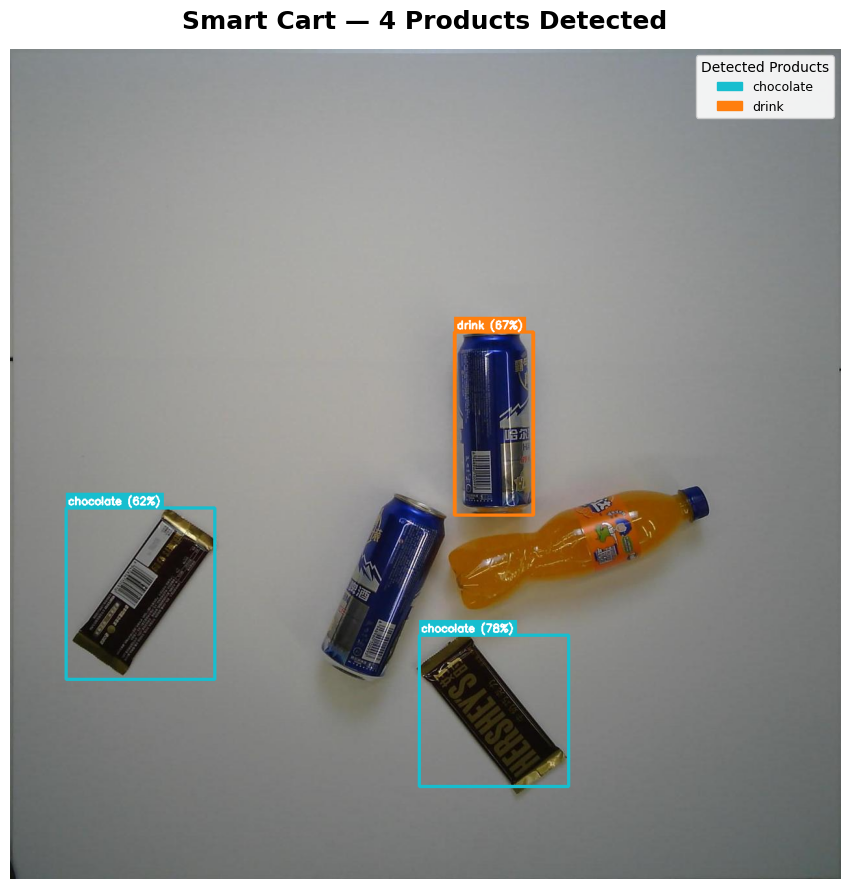


       🛒 VERIFY YOUR CART


Output()

Output()

In [23]:
# Upload Image & Smart Cart Analysis with Manual Review
# ------------------------------

import ipywidgets as widgets
from IPython.display import display, clear_output

# Manual Review Interface
def manual_review(detections, invoice_df, total, recs):
    current_cart = list(detections["product"]) if not detections.empty else []
    cart_state   = {"items": current_cart.copy()}

    cart_output  = widgets.Output()

    add_dropdown = widgets.Dropdown(
        options     = UNIQUE_CLEAN_NAMES,
        value       = UNIQUE_CLEAN_NAMES[0],
        description = "Add:",
        layout      = widgets.Layout(width="300px")
    )
    add_btn = widgets.Button(
        description  = "➕ Add Product",
        button_style = "success",
        layout       = widgets.Layout(width="160px")
    )

    delete_dropdown = widgets.Dropdown(
        options     = cart_state["items"] if cart_state["items"] else ["(empty)"],
        description = "Delete:",
        layout      = widgets.Layout(width="300px")
    )
    delete_btn = widgets.Button(
        description  = "🗑️ Delete Product",
        button_style = "danger",
        layout       = widgets.Layout(width="160px")
    )

    confirm_btn = widgets.Button(
        description  = "✅ Confirm & Pay",
        button_style = "primary",
        layout       = widgets.Layout(width="200px")
    )

    final_output = widgets.Output()

    def refresh_cart():
        with cart_output:
            clear_output(wait=True)
            if cart_state["items"]:
                counts = Counter(cart_state["items"])
                rows, total_price = [], 0.0
                for product, qty in counts.items():
                    price    = CATEGORY_PRICE.get(product, 3.0)
                    subtotal = round(price * qty, 2)
                    total_price += subtotal
                    rows.append({
                        "Product":        product,
                        "Qty":            qty,
                        "Price (SAR)":    price,
                        "Subtotal (SAR)": subtotal
                    })
                display(pd.DataFrame(rows))
                print(f"\n{'TOTAL:':<30} {total_price:.2f} SAR")
            else:
                print("Cart is empty.")
        delete_dropdown.options = cart_state["items"] if cart_state["items"] else ["(empty)"]

    def on_add(b):
        cart_state["items"].append(add_dropdown.value)
        refresh_cart()

    def on_delete(b):
        if delete_dropdown.value in cart_state["items"]:
            cart_state["items"].remove(delete_dropdown.value)
            refresh_cart()

    def on_confirm(b):
        with final_output:
            clear_output(wait=True)
            if not cart_state["items"]:
                print("Cart is empty.")
                return
            counts = Counter(cart_state["items"])
            rows, total_price = [], 0.0
            for product, qty in counts.items():
                price    = CATEGORY_PRICE.get(product, 3.0)
                subtotal = round(price * qty, 2)
                total_price += subtotal
                rows.append({
                    "Product":        product,
                    "Qty":            qty,
                    "Price (SAR)":    price,
                    "Subtotal (SAR)": subtotal
                })
            # Update cart display with confirmed cart
            with cart_output:
                clear_output(wait=True)
                display(pd.DataFrame(rows))
                print(f"\n{'TOTAL:':<30} {total_price:.2f} SAR")

            # Show recommendations
            recs = smart_recommendations(cart_state["items"])
            if not recs.empty:
                print("\n" + "="*45)
                print("         YOU MIGHT ALSO LIKE")
                print("="*45)
                display(recs)

            print("\n" + "="*45)
            print("    Thank you for shopping with us! 🛒")
            print("="*45)

    add_btn.on_click(on_add)
    delete_btn.on_click(on_delete)
    confirm_btn.on_click(on_confirm)

    print("\n" + "="*55)
    print("       🛒 VERIFY YOUR CART")
    print("="*55)
    refresh_cart()
    display(cart_output)
    display(widgets.HBox([add_dropdown,    add_btn]))
    display(widgets.HBox([delete_dropdown, delete_btn]))
    display(widgets.HBox([confirm_btn]))
    display(final_output)


# Customer Guidelines
print("""
╔══════════════════════════════════════════════════════╗
║         📸 SMART CART — GUIDELINES                  ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  Dear Customer, for accurate product scanning:       ║
║                                                      ║
║  ✅ Place your items flat on the scanning surface    ║
║  ✅ Spread products apart — avoid stacking them      ║
║  ✅ Keep items within the marked scanning area       ║
║                                                      ║                                                      ║
║  ⚠️  Overlapping items may affect scan accuracy     ║
║     You can add or remove items after scanning       ║
║                                                      ║
╚══════════════════════════════════════════════════════╝
""")

# Load CLIP descriptions from CSV
desc_df           = load_descriptions_csv()
CLIP_DESCRIPTIONS = dict(zip(desc_df["category"], desc_df["description"]))
CLIP_LABELS_DESC  = [CLIP_DESCRIPTIONS[name] for name in UNIQUE_CLEAN_NAMES]

# Upload image
uploaded = files.upload()

if uploaded:
    img_path = Path(list(uploaded.keys())[0])

    # Resize for better detection
    img         = Image.open(img_path)
    img_resized = img.resize((1280, 1280))
    resized_path = Path("/tmp/resized_test.jpg")
    img_resized.save(resized_path)

    # Run pipeline silently
    detections, invoice_df, total, recs = analyze(resized_path)

    # Show invoice
    if not detections.empty:
        manual_review(detections, invoice_df, total, recs)
    else:
        print("\n⚠️  No products detected.")
        print("Please place your items clearly on the scanning surface.")
        manual_review(pd.DataFrame(), pd.DataFrame(), 0.0, pd.DataFrame())

else:
    print("No image uploaded.")

**8: Evaluation Metrics**

           EVALUATION METRICS


,Product,True Qty,Pred Qty,Correct,Precision,Recall,F1 Score
0,chocolate,2,2,2,1.0,1.000,1.0
1,drink,3,2,2,1.0,0.667,0.8



Overall Accuracy: 0.800 (80.0%)


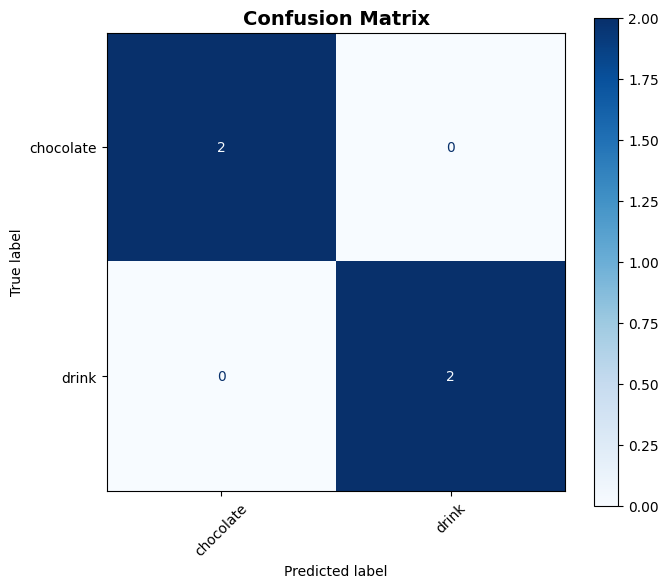

(     Product  True Qty  Pred Qty  Correct  Precision  Recall  F1 Score
 0  chocolate         2         2        2        1.0   1.000       1.0
 1      drink         3         2        2        1.0   0.667       0.8,
 0.8)

In [25]:
# Evaluation Metrics — Precision, Recall, F1 & Confusion Matrix
# Compare system detections against ground truth labels
# ------------------------------

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def evaluate_predictions(y_true, y_pred):
    """
    Evaluate detection + classification performance.
    y_true: list of actual products in the image
    y_pred: list of products detected by the system
    """
    if not y_true:
        print("Please provide true_labels.")
        return

    true_counts  = Counter(y_true)
    pred_counts  = Counter(y_pred)
    all_products = sorted(set(true_counts) | set(pred_counts))
    rows, total_correct = [], 0

    for product in all_products:
        tq      = true_counts.get(product, 0)
        pq      = pred_counts.get(product, 0)
        correct = min(tq, pq)
        total_correct += correct
        p  = correct/pq if pq else 0
        r  = correct/tq if tq else 0
        f1 = 2*p*r/(p+r) if (p+r) else 0
        rows.append({
            "Product":   product,
            "True Qty":  tq,
            "Pred Qty":  pq,
            "Correct":   correct,
            "Precision": round(p,3),
            "Recall":    round(r,3),
            "F1 Score":  round(f1,3)
        })

    df       = pd.DataFrame(rows)
    accuracy = total_correct / sum(true_counts.values())

    print("="*55)
    print("           EVALUATION METRICS")
    print("="*55)
    display(df)
    print(f"\nOverall Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

    # Confusion Matrix
    exp_t = sum([[p]*true_counts.get(p,0) for p in all_products], [])
    exp_p = sum([[p]*pred_counts.get(p,0) for p in all_products], [])
    n     = min(len(exp_t), len(exp_p))
    cm    = confusion_matrix(exp_t[:n], exp_p[:n], labels=all_products)

    fig, ax = plt.subplots(figsize=(max(7, len(all_products)*1.2),
                                    max(6, len(all_products))))
    ConfusionMatrixDisplay(cm, display_labels=all_products).plot(
        cmap="Blues", ax=ax, xticks_rotation=45)
    ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return df, accuracy


# Edit true_labels based on actual products in test image
true_labels      = ["drink", "drink", "chocolate", "chocolate", "drink"]
predicted_labels = list(detections["product"]) if not detections.empty else []

evaluate_predictions(true_labels, predicted_labels)